<a href="https://colab.research.google.com/github/rezve66/Rice-leaf-pca-analysis/blob/main/Collab%20Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 1000049605.jpg to 1000049605.jpg
✅ Analysis complete! Results saved in: /content/pca_results


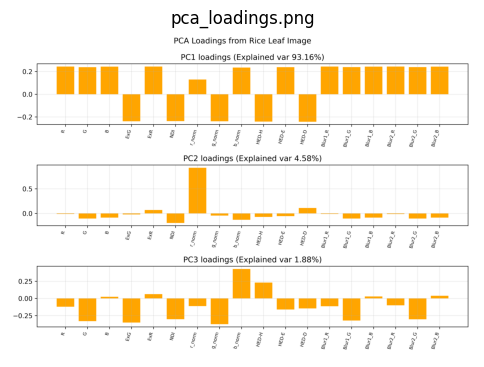

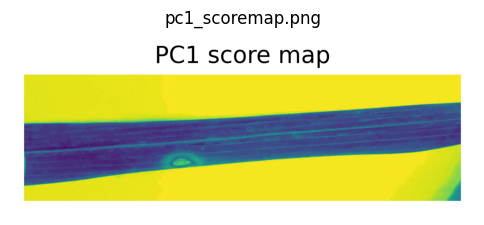

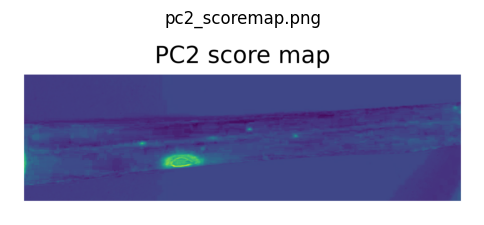

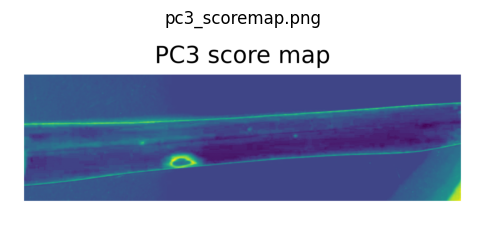

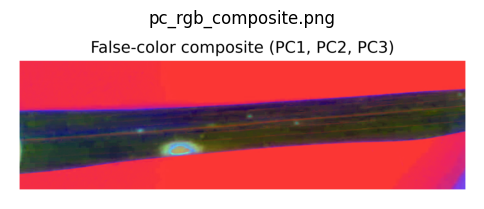

In [ ]:
# =========================
# 🔹 Install dependencies (if needed)
# =========================
!pip install scikit-image scikit-learn opencv-python matplotlib --quiet

# =========================
# 🔹 Import libraries
# =========================
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage.color import rgb2hed
from skimage.filters import gaussian
from pathlib import Path
from google.colab import files
import os

# =========================
# 🔹 PCA Function
# =========================
def run_rice_leaf_pca(image_path, out_dir="pca_results"):
    """
    Perform PCA on a single rice leaf RGB image to visualize infection-related patterns.
    Outputs:
      - PCA loadings plot
      - PC1, PC2, PC3 score maps
      - False-color RGB composite from (PC1,PC2,PC3)
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # --- Load image ---
    img = cv.imread(str(image_path), cv.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # --- White balance (gray-world assumption) ---
    means = img.reshape(-1, 3).mean(axis=0)
    scale = means.mean() / np.maximum(means, 1e-6)
    img_wb = np.clip(img * scale, 0, 1)

    # --- Feature extraction ---
    H, W, _ = img_wb.shape
    R, G, B = img_wb[..., 0], img_wb[..., 1], img_wb[..., 2]
    eps = 1e-6
    exg = 2 * G - R - B
    exr = 1.4 * R - G
    ndi = (G - R) / (G + R + eps)
    rgb_sum = R + G + B + eps
    r_norm, g_norm, b_norm = R / rgb_sum, G / rgb_sum, B / rgb_sum

    features = [img_wb,
                exg[..., None], exr[..., None], ndi[..., None],
                r_norm[..., None], g_norm[..., None], b_norm[..., None]]

    # HED color deconvolution (optional)
    hed_added = False
    try:
        hed = rgb2hed(np.clip(img_wb, 0, 1))
        features += [hed[..., 0, None], hed[..., 1, None], hed[..., 2, None]]
        hed_added = True
    except Exception:
        pass

    # Blurred versions
    features += [gaussian(img_wb, sigma=1, channel_axis=-1),
                 gaussian(img_wb, sigma=2, channel_axis=-1)]

    F = np.concatenate(features, axis=-1).astype(np.float32)

    # --- Z-score normalization ---
    X = F.reshape(-1, F.shape[-1])
    mu, sd = X.mean(axis=0), X.std(axis=0) + 1e-6
    Xz = (X - mu) / sd

    # --- PCA ---
    pca = PCA(n_components=3, random_state=0).fit(Xz)
    scores = pca.transform(Xz).reshape(H, W, 3)
    loadings = pca.components_
    explained = pca.explained_variance_ratio_

    # Feature names
    base_names = ["R", "G", "B", "ExG", "ExR", "NDI", "r_norm", "g_norm", "b_norm"]
    hed_names = ["HED-H", "HED-E", "HED-D"] if hed_added else []
    blur_names = ["Blur1_R", "Blur1_G", "Blur1_B", "Blur2_R", "Blur2_G", "Blur2_B"]
    all_names = base_names + hed_names + blur_names
    feature_names = all_names[:F.shape[-1]]

    # --- Save PCA loadings plot ---
    figL, axes = plt.subplots(3, 1, figsize=(10, 7))
    for i, ax in enumerate(axes):
        ax.bar(range(loadings.shape[1]), loadings[i], color="orange")
        ax.set_xticks(range(len(feature_names)))
        ax.set_xticklabels(feature_names, rotation=75, ha='right', fontsize=7)
        ax.set_title(f"PC{i+1} loadings (Explained var {explained[i]:.2%})")
        ax.grid(True, alpha=0.3)
    figL.suptitle("PCA Loadings from Rice Leaf Image")
    plt.tight_layout()
    figL.savefig(out_dir / "pca_loadings.png", dpi=600)
    plt.close(figL)

    # --- Save score maps ---
    for k in range(3):
        sm = scores[..., k]
        smn = (sm - sm.min()) / (sm.max() - sm.min() + 1e-6)
        plt.figure(figsize=(4, 4))
        plt.imshow(smn, cmap="viridis")
        plt.axis('off')
        plt.title(f"PC{k+1} score map")
        plt.savefig(out_dir / f"pc{k+1}_scoremap.png", dpi=600, bbox_inches="tight")
        plt.close()

    # --- Save false-color composite (PC1, PC2, PC3 as RGB) ---
    pc_rgb = np.zeros_like(scores)
    for i in range(3):
        sm = scores[..., i]
        pc_rgb[..., i] = (sm - sm.min()) / (sm.max() - sm.min() + 1e-6)
    plt.figure(figsize=(6, 6))
    plt.imshow(pc_rgb)
    plt.axis('off')
    plt.title("False-color composite (PC1, PC2, PC3)")
    plt.savefig(out_dir / "pc_rgb_composite.png", dpi=600, bbox_inches="tight")
    plt.close()

    print(f"✅ Analysis complete! Results saved in: {out_dir.resolve()}")

    # Show results inline
    for img_file in ["pca_loadings.png", "pc1_scoremap.png", "pc2_scoremap.png", "pc3_scoremap.png", "pc_rgb_composite.png"]:
        path = out_dir / img_file
        if path.exists():
            img_disp = plt.imread(str(path))
            plt.figure(figsize=(6, 6))
            plt.imshow(img_disp)
            plt.axis('off')
            plt.title(img_file)
            plt.show()

# =========================
# 🔹 Upload and Analyze
# =========================
uploaded = files.upload()  # Upload image interactively
image_path = list(uploaded.keys())[0]  # Get uploaded file name
run_rice_leaf_pca(image_path, out_dir="pca_results")
